# Bank Customer Churn Prediction

## Notebook 1: Data Understanding

### Objective

The objective of this notebook is to explore the banking customer churn dataset, understand its structure, identify data quality issues, and gain an initial understanding of the variables before data preprocessing and model development.

In [79]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")



## Load the Dataset

In [80]:
from pathlib import Path


DATA_PATH = Path("C:/Users/nount/OneDrive/Desktop/Six months Bootcamp 18 October 2025/00 MBA/0 Data science 5000/Bank-Customer-Churn-Prediction/data/raw")

df = pd.read_csv(DATA_PATH / "Banking_Churn.csv")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Observations

The first five rows confirm that the dataset has been loaded successfully.
Each row represents one customer, while each column represents a customer attribute such as age, balance, or tenure.

## Dataset Overview

Before performing any analysis or preprocessing, it is important to understand the structure of the dataset. This includes the number of observations, variables, data types, and whether any missing values are present. This initial inspection helps identify potential data quality issues and guides the preprocessing stage.

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


### Observations

The dataset contains **10,000 customer records** and **12 variables**, including customer demographic, financial, and banking information. There are **no missing values**, indicating that the dataset is complete and ready for further analysis. The variables consist of **8 integer**, **2 floating-point**, and **2 categorical (string)** features. The target variable is **`churn`**, which indicates whether a customer has left the bank.

## Dataset Dimensions

The next step is to examine the dimensions of the dataset. Understanding the number of observations and variables helps determine whether the dataset is suitable for machine learning analysis.

In [82]:
rows, columns = df.shape

print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 10000
Number of columns: 12


### Observations

The dataset contains **10,000 observations** and **12 variables**. The number of observations is sufficient for training and evaluating machine learning classification models. The variables represent customer characteristics that may influence the likelihood of customer churn.

## Variable Names

Before analyzing the data, it is important to identify the available variables and understand what each one represents. This helps determine which variables may be useful predictors of customer churn and which variables may require preprocessing.

In [83]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='str')

### Observations

The dataset contains customer demographic, financial, and banking relationship variables. The target variable is **`churn`**, while **`customer_id`** uniquely identifies each customer and is not expected to contribute to predicting customer churn. It will likely be removed before model training because it does not contain predictive information.

## Variable Classification

Before building machine learning models, it is important to classify each variable according to its data type and role in the analysis. This helps determine how each variable should be preprocessed and whether it should be included in the predictive model.

In [84]:
df.dtypes

customer_id           int64
credit_score          int64
country                 str
gender                  str
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

### Observations

The dataset contains a mixture of numerical, categorical, binary, and identifier variables. The numerical variables describe customer characteristics such as age, credit score, balance, and estimated salary. The categorical variables include country and gender, while credit card ownership and active membership are binary variables represented as 0 and 1. The variable `customer_id` is an identifier and will not be used for model training because it does not provide predictive information. The target variable is `churn`, which indicates whether a customer left the bank.

## Target Variable Distribution

The first step in a classification problem is to understand the distribution of the target variable. This analysis shows how many customers stayed with the bank and how many customers churned. It also helps determine whether the dataset is balanced or imbalanced, which may influence model performance and evaluation.

In [85]:

df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

### Business Insight

Although approximately 80% of customers remained with the bank, this does not mean that a model predicting every customer will stay would be useful. Such a model would achieve nearly 80% accuracy while failing to identify any customers at risk of churning. Therefore, accuracy alone is not an appropriate performance measure for this project, and additional metrics such as precision, recall, F1-score, and ROC-AUC will also be considered.

## Visualizing the Target Variable

A graphical representation of the target variable provides a clearer understanding of the proportion of customers who stayed and those who churned. Visualizations make it easier to identify class imbalance and communicate findings to both technical and non-technical audiences.

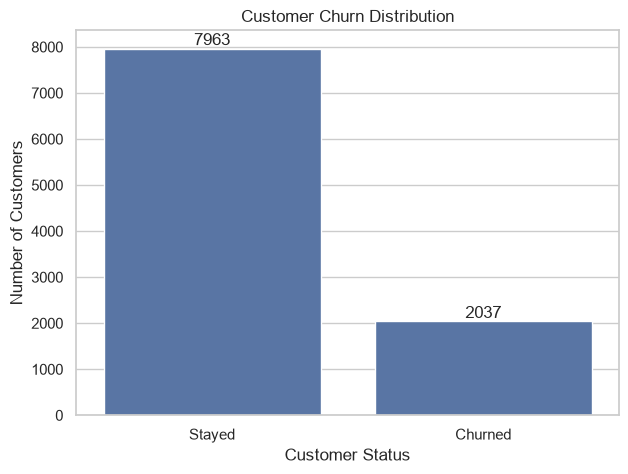

In [86]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x="churn")

ax.set_xticklabels(["Stayed", "Churned"])

# Add the counts above each bar
for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

### Observations

The bar chart confirms that substantially more customers remained with the bank than churned. Approximately 80% of customers stayed, while about 20% left the bank. This visual evidence confirms that the dataset is imbalanced, meaning the majority class is considerably larger than the minority class. As a result, relying solely on accuracy to evaluate machine learning models could be misleading, making additional evaluation metrics such as recall, precision, F1-score, and ROC-AUC essential.

# Relationship Between Age and Customer Churn

Age is one of the most important demographic variables in banking. In this section, we examine whether customer age is associated with churn by comparing the age distributions of customers who stayed with those who left the bank.

In [87]:
df.groupby("churn")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,37.408389,10.125363,18.0,31.0,36.0,41.0,92.0
1,2037.0,44.837997,9.761562,18.0,38.0,45.0,51.0,84.0


### Observations

Customers who churned have a noticeably higher average age (44.8 years) than customers who remained with the bank (37.4 years). The median age also differs substantially (45 versus 36 years), suggesting that older customers are more likely to leave the bank. This finding contradicts the initial hypothesis that younger customers would be more likely to churn, highlighting the importance of validating assumptions with data rather than relying solely on intuition. The similar mean and median values within each group indicate that the age distributions are reasonably symmetric.

## Age Distribution by Customer Churn

While summary statistics provide useful numerical information, they do not reveal the full distribution of customer ages. A boxplot allows us to compare the age distributions of customers who stayed and those who churned, helping identify differences in central tendency, variability, and potential outliers.

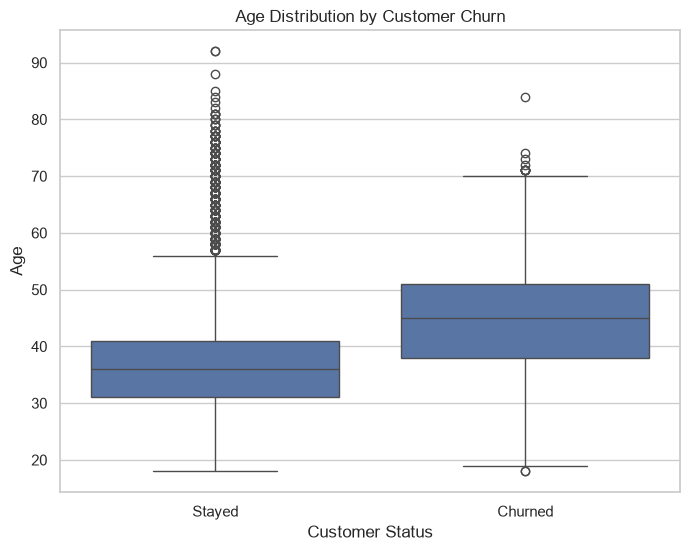

In [88]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="churn",
    y="age"
)

plt.xticks([0,1],["Stayed","Churned"])

plt.title("Age Distribution by Customer Churn")

plt.xlabel("Customer Status")

plt.ylabel("Age")

plt.show()

## Selecting Numerical Variables

Before automating the exploratory data analysis, we first identify the numerical variables that will be examined. Automating repetitive analyses improves efficiency and allows us to focus on interpreting business insights rather than writing repetitive code.

In [89]:
numerical_columns = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

numerical_columns

['credit_score',
 'age',
 'tenure',
 'balance',
 'products_number',
 'estimated_salary']

In [90]:
for column in numerical_columns:

    print("=" * 60)
    print(f"Summary Statistics for: {column}")
    print("=" * 60)

    display(df.groupby("churn")[column].describe())

    print("\n")

Summary Statistics for: credit_score


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,651.853196,95.653837,405.0,585.0,653.0,718.0,850.0
1,2037.0,645.351497,100.321503,350.0,578.0,646.0,716.0,850.0




Summary Statistics for: age


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,37.408389,10.125363,18.0,31.0,36.0,41.0,92.0
1,2037.0,44.837997,9.761562,18.0,38.0,45.0,51.0,84.0




Summary Statistics for: tenure


...

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,72745.296779,62848.040701,0.0,0.00,92072.68,126410.28,221532.80
1,2037.0,91108.539337,58360.794816,0.0,38340.02,109349.29,131433.33,250898.09




Summary Statistics for: products_number


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,1.544267,0.509536,1.0,1.0,2.0,2.0,3.0
1,2037.0,1.475209,0.801521,1.0,1.0,1.0,2.0,4.0




Summary Statistics for: estimated_salary


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,99738.391772,57405.586966,90.07,50783.49,99645.04,148609.955,199992.48
1,2037.0,101465.677531,57912.418071,11.58,51907.72,102460.84,152422.910,199808.10


## Creating a Reusable Visualization Function

Instead of writing separate code for every numerical variable, we create a reusable Python function. This follows good programming practices by reducing repetition and making the code easier to maintain. The function can generate the same visualization for any numerical feature in the dataset.

In [95]:
def plot_boxplot(variable):

    plt.figure(figsize=(8,6))

    sns.boxplot(
        data=df,
        x="churn",
        y=variable
    )

    plt.xticks([0,1],["Stayed","Churned"])

    plt.title(f"{variable.replace('_',' ').title()} by Customer Status")

    plt.xlabel("Customer Status")

    plt.ylabel(variable.replace("_"," ").title())

    plt.show()

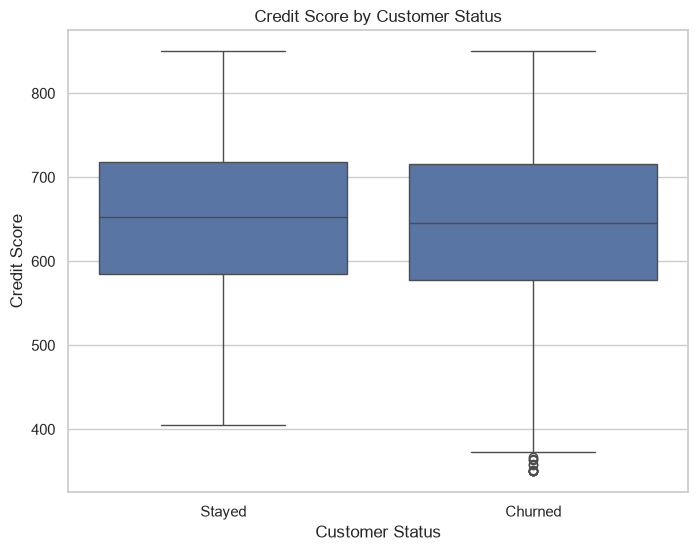

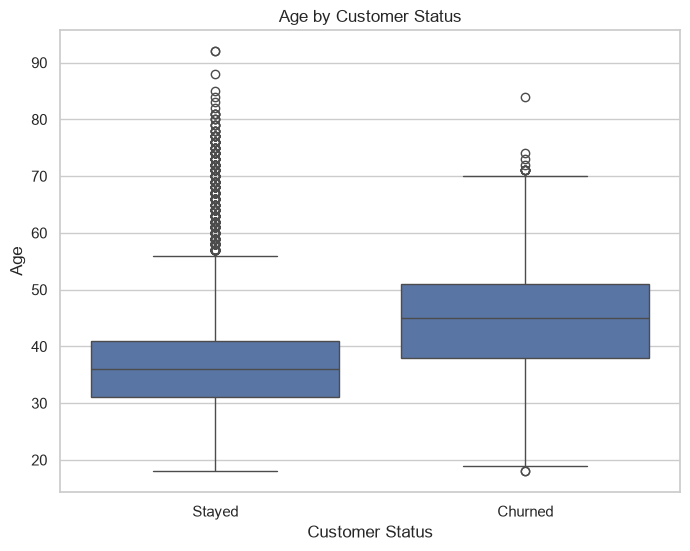

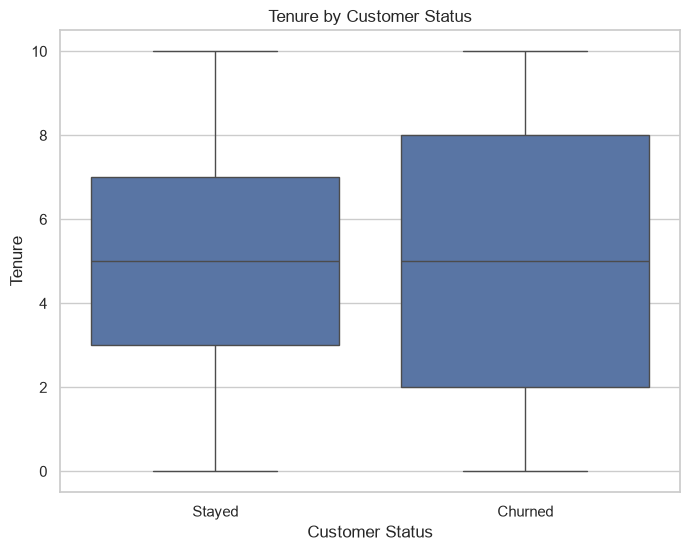

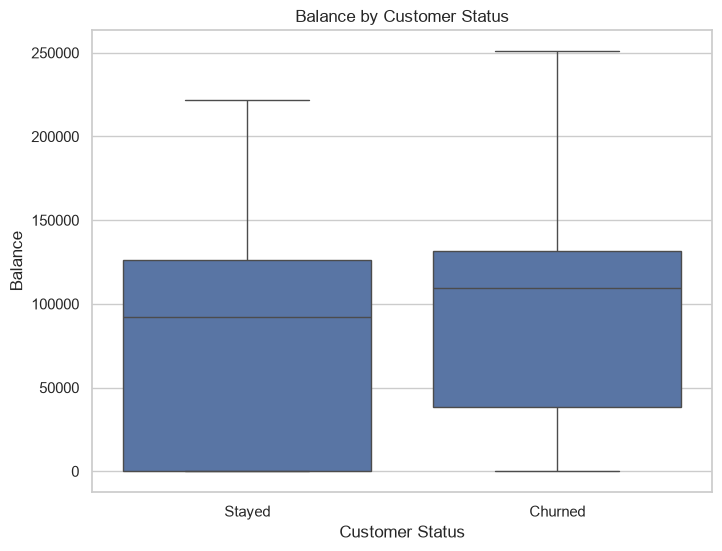

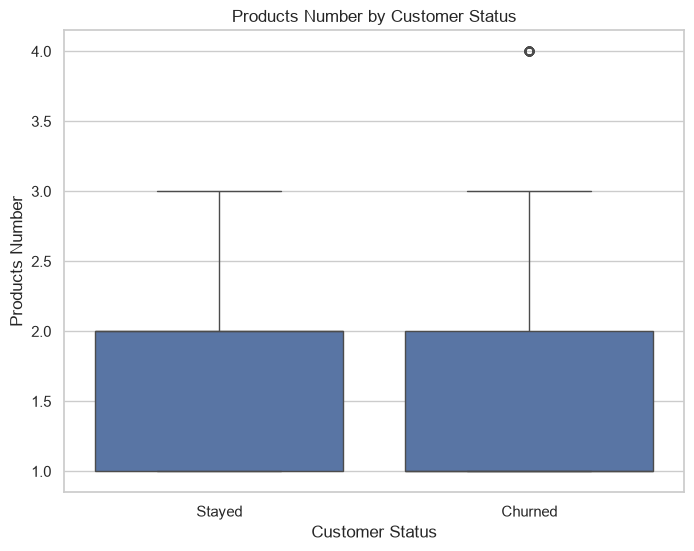

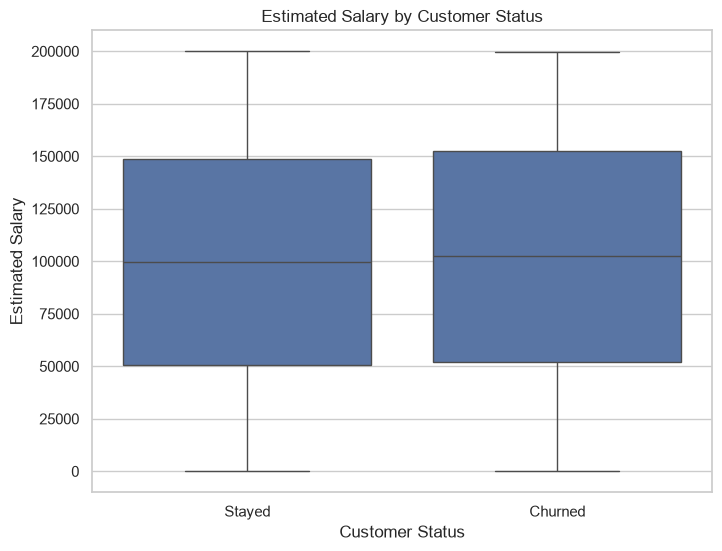

In [97]:
for column in numerical_columns:

    plot_boxplot(column)

# Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between numerical variables. Understanding these relationships helps identify variables that may contain similar information, reveal important customer characteristics, and support feature selection before building machine learning models.

In [98]:
correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,credit_score,age,tenure,balance,products_number,estimated_salary
credit_score,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384
age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201
tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784
balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797
products_number,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204
estimated_salary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000


### Why Correlation Matters

Correlation helps identify relationships between numerical variables by measuring how strongly they move together. Strong correlations can reveal useful patterns, identify redundant variables, and support feature selection. However, correlation does not imply causation. A strong correlation indicates an association between variables but does not prove that one variable causes changes in the other. Business context and domain knowledge remain essential when interpreting correlation results.

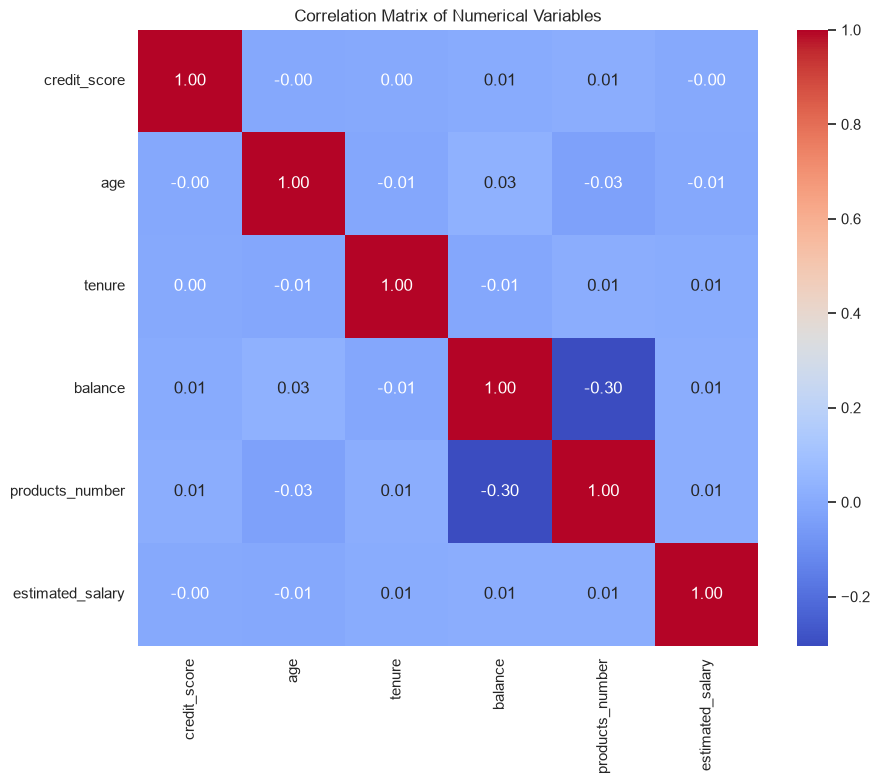

In [99]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

# Customer Activity and Churn

Customer activity may be an important indicator of customer engagement. In this section, we examine whether active members are less likely to churn than inactive members by comparing churn rates across the two groups.

In [100]:
df.groupby("active_member")["churn"].mean()

active_member
0    0.268509
1    0.142691
Name: churn, dtype: float64

In [101]:
churn_rate = (
    df.groupby("active_member")["churn"]
      .mean()
      .reset_index()
)

churn_rate

,active_member,churn
0,0,0.268509
1,1,0.142691


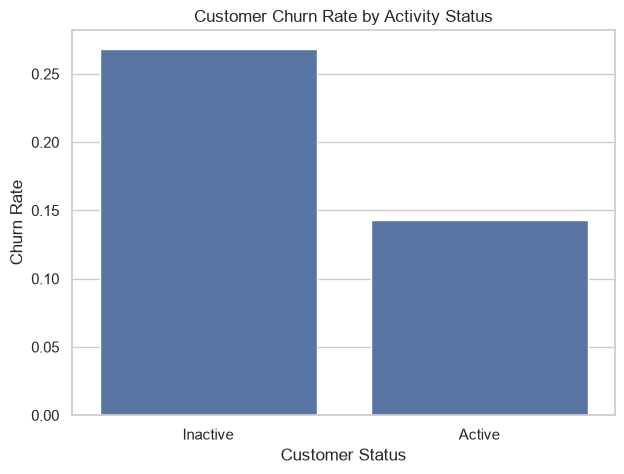

In [102]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=churn_rate,
    x="active_member",
    y="churn"
)

ax.set_xticklabels(["Inactive","Active"])

plt.title("Customer Churn Rate by Activity Status")

plt.xlabel("Customer Status")

plt.ylabel("Churn Rate")

plt.show()

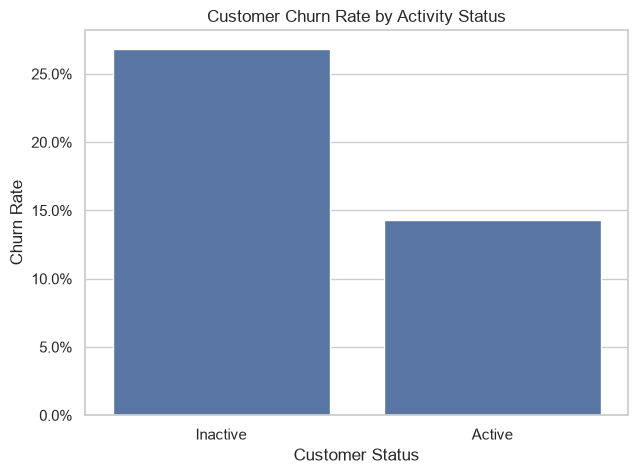

In [103]:
import matplotlib.ticker as mtick

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=churn_rate,
    x="active_member",
    y="churn"
)

ax.set_xticklabels(["Inactive","Active"])

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title("Customer Churn Rate by Activity Status")

plt.xlabel("Customer Status")

plt.ylabel("Churn Rate")

plt.show()

In [104]:
categorical_columns = [
    "gender",
    "country",
    "active_member",
    "credit_card"
]

categorical_columns

['gender', 'country', 'active_member', 'credit_card']

In [ ]:
def plot_churn_rate(variable):

    churn_rate = (
        df.groupby(variable)["churn"]
          .mean()
          .reset_index()
    )

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        data=churn_rate,
        x=variable,
        y="churn"
    )

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.title(f"Churn Rate by {variable.replace('_',' ').title()}")

    plt.xlabel(variable.replace("_"," ").title())

    plt.ylabel("Churn Rate")

    plt.show()


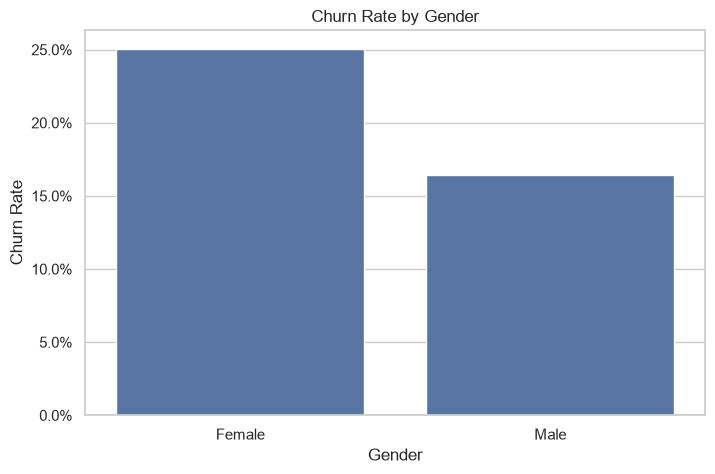

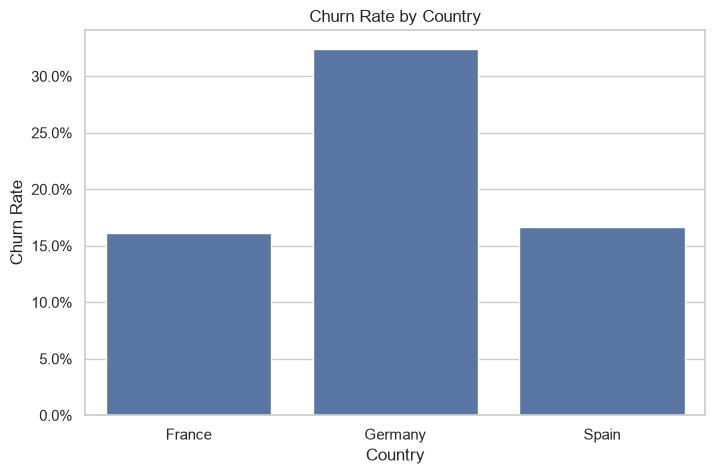

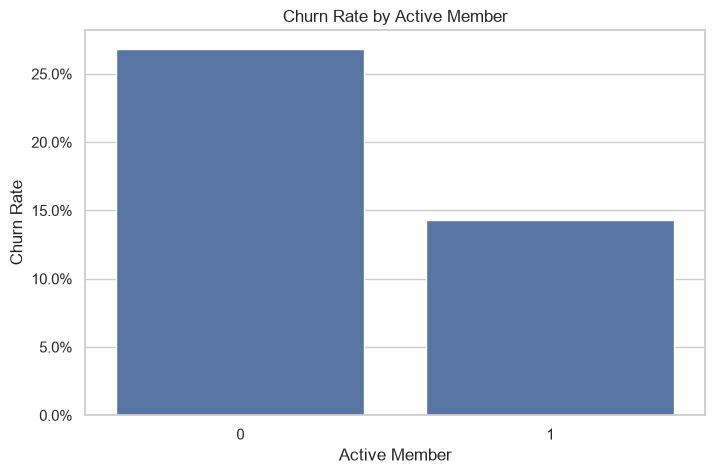

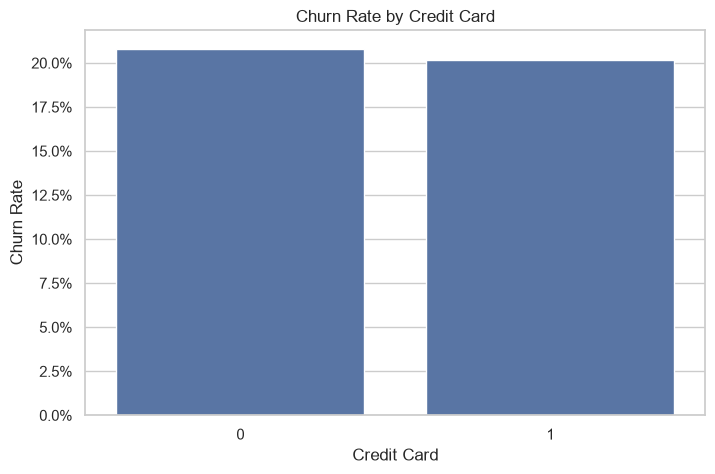

In [106]:
for column in categorical_columns:

    plot_churn_rate(column)